# Who Lives There? The Tiny Life in Boyce Park Pond

**CMU Pre-College Computational Biology, Module 2. Group A3 (Alphas): Thomas Yu, Thomas Kellog, Lexi Dai, Sarah Wu.**

We read the DNA of the bacteria and algae in Boyce Park pond water to find out who lives there, and whether old coal mine runoff is shaping the pond. We identify the most common living things ourselves, check how sure we can be, and compare the pond to the city rivers. Every step below has a short, plain explanation so anyone can follow along.

**[Click here to run every cell in Google Colab.](https://colab.research.google.com/github/TomAs-1226/who-lives-there-boyce-park/blob/main/Boyce_Park_Taxonomy.ipynb)** Each cell runs on its own, top to bottom.

## Step 0: Load the data
Open the files the lab gave us: one set for our pond, and one shared set that also has the rivers and the clean water controls. The lab already read the DNA and cleaned it up, so we get tidy tables instead of raw machine output. That lets us start straight from the results and do our own checks on them.

In [1]:
# Colab already has the number and chart tools. Biopython is only used if you redo the DNA search live.
!pip -q install biopython

import os, io, csv, json, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.max_colwidth", 90)
print("ready")


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


ready


The two data folders live in this repo, or in your Google Drive. This cell finds them either way.

In [2]:
DATA_ROOT = None
for place in ['.', 'data']:
    if os.path.exists(os.path.join(place, 'House1_Boyce_Park_2025', 'feature-table.tsv')):
        DATA_ROOT = place; break
if DATA_ROOT is None:
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        DATA_ROOT = '/content/drive/MyDrive/Taxonomic Project Data'   # change to your folder
    except Exception:
        DATA_ROOT = '.'

BP   = os.path.join(DATA_ROOT, 'House1_Boyce_Park_2025')
BASE = os.path.join(DATA_ROOT, 'Baseline_AllSamples_2025')
ok = os.path.exists(os.path.join(BP, 'feature-table.tsv'))
print('Our pond folder:', BP, '| found:', ok)
assert ok, 'Could not find the pond folder. Set DATA_ROOT to your Drive folder.'


Our pond folder: data\House1_Boyce_Park_2025 | found: True


Small helpers that open the files. Nothing to see here.

In [3]:
def load_table(folder):
    df = pd.read_csv(os.path.join(folder, 'feature-table.tsv'), sep='\t', skiprows=1, dtype=str)
    df = df.rename(columns={df.columns[0]: 'feature_id'})
    if 'taxonomy' in df.columns: df = df.drop(columns=['taxonomy'])
    return df.set_index('feature_id').astype(float)

def load_taxonomy(folder):
    t = pd.read_csv(os.path.join(folder, 'taxonomy.tsv'), sep='\t', dtype=str)
    t.columns = ['feature_id', 'taxon', 'confidence'][:len(t.columns)]
    return t.set_index('feature_id')

def load_mapping(folder):
    m = pd.read_csv(os.path.join(folder, 'mapping_file.txt'), sep='\t', dtype=str)
    return m.rename(columns={m.columns[0]: 'SampleID'}).set_index('SampleID')

def load_fasta(folder):
    seqs, fid = {}, None
    for line in open(os.path.join(folder, 'dna-sequences.fasta')):
        line = line.strip()
        if line.startswith('>'): fid = line[1:].split()[0]; seqs[fid] = ''
        elif fid: seqs[fid] += line
    return seqs

def rank_of(taxon, prefix):
    if not isinstance(taxon, str): return None
    for part in taxon.split(';'):
        part = part.strip()
        if part.startswith(prefix): return part[len(prefix):].strip() or None
    return None

def deepest(taxon):
    # the most detailed REAL name the lab gave: genus if it has one, otherwise
    # family, order, class, or phylum. Skips vague labels like "uncultured".
    vague = ('uncultured', 'unidentified', 'metagenome', 'unknown')
    for pre, suf in [('g__',''),('f__',' (family)'),('o__',' (order)'),('c__',' (class)'),('p__',' (phylum)')]:
        v = rank_of(taxon, pre)
        if v and not any(b in v.lower() for b in vague): return v + suf
    return 'other'

bp   = load_table(BP);   btax = load_taxonomy(BP);   bmap = load_mapping(BP);   bseq = load_fasta(BP)
base = load_table(BASE); basetax = load_taxonomy(BASE); basemap = load_mapping(BASE)
bmap['spot'] = bmap['TreatmentGroup'].map(lambda tg: 'BP' + tg.strip().split()[-1])
samples = list(bp.columns)
print('Our pond:', len(samples), 'samples,', bp.shape[0], 'kinds of microbe,', int(bp.values.sum()), 'DNA reads.')
print(bmap['spot'].value_counts().to_string())

Our pond: 10 samples, 5818 kinds of microbe, 882619 DNA reads.
spot
BP2    3
BP4    3
BP1    2
BP5    2


## Step 1: Name the microbes ourselves

We take the **20 most common microbes** (about two thirds of everything in the pond) and look up each one's DNA with **BLAST**, a free NIH tool that finds the closest known match in a giant library. It is the same search and score idea as our aligner project, just at full scale. We only do the top 20 because looking up thousands by hand is not realistic, and those 20 already tell most of the story. For each one, BLAST hands back the closest named organism and a score for how good the match is.

In [4]:
totals = bp.sum(axis=1).sort_values(ascending=False)
top20_ids = list(totals.head(20).index)
grand = totals.sum()
top20 = pd.DataFrame({
    'feature_id': top20_ids,
    'percent_of_pond': (100*totals[top20_ids]/grand).round(2).values,
    'lab_name': btax['taxon'].reindex(top20_ids).values,
    'lab_confidence': btax['confidence'].reindex(top20_ids).astype(float).round(3).values,
})
top20.index = range(1, 21); top20.index.name = 'rank'
print('The top 20 are', round(top20['percent_of_pond'].sum(),1), 'percent of the pond.')
top20[['feature_id','percent_of_pond','lab_confidence','lab_name']]

The top 20 are 66.1 percent of the pond.


,feature_id,percent_of_pond,lab_confidence,lab_name
rank,,,,
1,821495,34.34,0.997,d__Bacteria; p__Proteobacteria; c__Gammaproteobacteria; o__Burkholderiales
2,4402734,10.75,1.000,d__Bacteria; p__Cyanobacteria; c__Cyanobacteriia; o__Chloroplast; f__Chloroplast; g__C...
3,550329,5.86,1.000,d__Bacteria; p__Cyanobacteria; c__Cyanobacteriia; o__Chloroplast; f__Chloroplast; g__C...
4,4203120,2.31,1.000,d__Bacteria; p__Actinobacteriota; c__Acidimicrobiia; o__uncultured; f__uncultured; g__...
5,4327233,1.97,0.999,d__Bacteria; p__Actinobacteriota; c__Actinobacteria; o__Micrococcales; f__Microbacteri...
6,254922,1.84,0.813,d__Bacteria; p__Proteobacteria; c__Alphaproteobacteria; o__Acetobacterales; f__Acetoba...
7,1140775,1.15,0.996,d__Bacteria; p__Actinobacteriota; c__Acidimicrobiia; o__uncultured; f__uncultured; g__...
8,283765,0.97,0.917,d__Bacteria; p__Actinobacteriota; c__Actinobacteria; o__Micrococcales; f__Micrococcace...
9,13505,0.94,1.000,d__Bacteria; p__Actinobacteriota; c__Acidimicrobiia; o__uncultured; f__uncultured; g__...


In [5]:
# save the 20 DNA tags to the file BLAST reads
with open('top20.fasta','w') as f:
    for fid in top20_ids: f.write('>'+fid+'\n'+bseq[fid]+'\n')
print('Saved 20 DNA tags.')

Saved 20 DNA tags.


The lookups are slow online, so we **saved the results inside this notebook**. To redo them live, set `RUN_BLAST_LIVE = True`.

In [6]:
RUN_BLAST_LIVE = False   # True = look the 20 tags up online again

def blast_top20():
    from Bio.Blast import NCBIWWW, NCBIXML
    skip = ('uncultured','environmental','metagenome','unidentified','bacterium clone','unknown')
    rows = []
    for i, fid in enumerate(top20_ids, 1):
        h = NCBIWWW.qblast('blastn','nt', bseq[fid], hitlist_size=15, megablast=True)
        rec = NCBIXML.read(io.StringIO(h.read())); h.close()
        def row(a):
            hsp=a.hsps[0]
            return (a.accession, a.hit_def.split('>')[0].strip(),
                    round(100*hsp.identities/hsp.align_length,2), '%.1e'%hsp.expect)
        if rec.alignments:
            top = row(rec.alignments[0])
            named = next((row(a) for a in rec.alignments if not any(s in a.hit_def.lower() for s in skip)), top)
        else:
            top = ('','no match',0.0,''); named = top
        rows.append([i, fid, *top, named[0], named[1], named[2]])
        print(i, fid, top[2], top[1][:45])
    return pd.DataFrame(rows, columns=['rank','feature_id','top_accession','top_match','top_percent_match',
                                       'top_evalue','named_accession','named_match','named_percent_match'])

CACHED_BLAST_TSV = r'''rank	feature_id	top_accession	top_hit_def	top_pident	top_evalue	top_bitscore	named_accession	named_hit_def	named_pident
1	821495	JF817232	Uncultured bacterium clone Bac-1-78 16S ribosomal RNA gene, partial sequence	99.14	0.0e+00	837.7	KC677654	Ferrovum sp. PN-J174 16S ribosomal RNA gene, partial sequence	99.14
2	4402734	KC683316	Uncultured bacterium clone F27 16S ribosomal RNA gene, partial sequence	99.32	0.0e+00	804.4	NC_024928	Eunotia naegelii chloroplast, complete genome	99.32
3	550329	FJ612436	Uncultured bacterium clone DP10.5.15 16S ribosomal RNA gene, partial sequence	97.51	0.0e+00	756.4	LC648951	Cryptomonas curvata NIES-281 chloroplast DNA, complete genome	96.83
4	4203120	HQ420135	Uncultured bacterium clone LRE22B39 16S ribosomal RNA gene, partial sequence	99.32	0.0e+00	800.7	HQ420135	Uncultured bacterium clone LRE22B39 16S ribosomal RNA gene, partial sequence	99.32
5	4327233	OR144289	Curtobacterium citreum strain CvEBI-9 16S ribosomal RNA gene, partial sequence	99.33	0.0e+00	806.3	OR144289	Curtobacterium citreum strain CvEBI-9 16S ribosomal RNA gene, partial sequence	99.33
6	254922	NR_159185	Acidocella aquatica strain Ok2G 16S ribosomal RNA, partial sequence	99.09	0.0e+00	791.5	NR_159185	Acidocella aquatica strain Ok2G 16S ribosomal RNA, partial sequence	99.09
7	1140775	GU557032	Uncultured bacterium isolate DGGE gel band pta1A-70 16S ribosomal RNA gene, partial sequence	99.32	0.0e+00	800.7	GU557032	Uncultured bacterium isolate DGGE gel band pta1A-70 16S ribosomal RNA gene, partial sequence	99.32
8	283765	JF107358	Uncultured bacterium clone ncd1277e03c1 16S ribosomal RNA gene, partial sequence	99.55	0.0e+00	811.8	MW547171	Kocuria sp. strain S1_16.1.3 16S ribosomal RNA gene, partial sequence	99.33
9	13505	X92701	Uncultured Actinomycetales bacterium 16S ribosomal RNA (clone TM177)	99.32	0.0e+00	800.7	X92701	Uncultured Actinomycetales bacterium 16S ribosomal RNA (clone TM177)	99.32
10	3538	NC_082073	Klebsormidium nitens strain MVSP plastid, complete genome	99.34	0.0e+00	821.0	NC_082073	Klebsormidium nitens strain MVSP plastid, complete genome	99.34
11	219317	DQ906069	Uncultured bacterium clone ERF-C9 16S ribosomal RNA gene, partial sequence	99.32	0.0e+00	800.7	DQ906069	Uncultured bacterium clone ERF-C9 16S ribosomal RNA gene, partial sequence	99.32
12	647790	EF221487	Uncultured alpha proteobacterium clone SI-1M_F10 16S ribosomal RNA gene, partial sequence	99.32	0.0e+00	797.0	EF221487	Uncultured alpha proteobacterium clone SI-1M_F10 16S ribosomal RNA gene, partial sequence	99.32
13	1113279	KC619579	Uncultured bacterium clone CN4m-bac_e6 16S ribosomal RNA gene, partial sequence	99.32	0.0e+00	797.0	KC924950	Acidiphilium rubrum strain Colony12 16S ribosomal RNA gene, partial sequence	99.32
14	683891	JQ385613	Uncultured bacterium clone MD10h7_267 16S ribosomal RNA gene, partial sequence	99.55	0.0e+00	802.6	JQ385613	Uncultured bacterium clone MD10h7_267 16S ribosomal RNA gene, partial sequence	99.55
15	4203118	KF581207	Uncultured bacterium clone CAMD_CTRL_B1B6 16S ribosomal RNA gene, partial sequence	98.64	0.0e+00	780.4	KF581207	Uncultured bacterium clone CAMD_CTRL_B1B6 16S ribosomal RNA gene, partial sequence	98.64
16	1047041	GQ058319	Uncultured bacterium clone nbw1079b05c1 16S ribosomal RNA gene, partial sequence	99.55	0.0e+00	811.8	GQ058319	Uncultured bacterium clone nbw1079b05c1 16S ribosomal RNA gene, partial sequence	99.55
17	1121839	LK024969	Uncultured bacterium partial 16S rRNA gene, clone BProP8A06	99.32	0.0e+00	797.0	LK024969	Uncultured bacterium partial 16S rRNA gene, clone BProP8A06	99.32
18	4453684	HE604017	Uncultured bacterium partial 16S rRNA gene, clone Central-Bottom-cDNA_clone5	99.14	0.0e+00	837.7	HE604017	Uncultured bacterium partial 16S rRNA gene, clone Central-Bottom-cDNA_clone5	99.14
19	169182	KX956779	Uncultured bacterium clone OTU2432 16S ribosomal RNA gene, partial sequence	99.57	0.0e+00	848.7	CP046022	Enterococcus faecalis strain BFF1B1 chromosome, complete genome	99.57
20	150673	LT721355	Uncultured bacterium partial 16S rRNA gene, clone 108.1_1006040	99.77	0.0e+00	808.1	PV902520	Sphingomonas sp. strain A4e 16S ribosomal RNA gene, partial sequence	99.32
'''
if RUN_BLAST_LIVE:
    blast = blast_top20(); blast.to_csv('top20_blast_results.tsv', sep='\t', index=False)
else:
    blast = pd.read_csv(io.StringIO(CACHED_BLAST_TSV), sep='\t')
blast = blast.rename(columns={'top_hit_def':'top_match','top_pident':'top_percent_match',
                              'named_hit_def':'named_match','named_pident':'named_percent_match'})
blast['feature_id'] = blast['feature_id'].astype(str)
# "top match" = the very closest DNA; "named match" = the closest one with a real organism name
blast[['rank','feature_id','top_percent_match','top_match','named_match']]

,rank,feature_id,top_percent_match,top_match,named_match
0,1,821495,99.14,"Uncultured bacterium clone Bac-1-78 16S ribosomal RNA gene, partial sequence","Ferrovum sp. PN-J174 16S ribosomal RNA gene, partial sequence"
1,2,4402734,99.32,"Uncultured bacterium clone F27 16S ribosomal RNA gene, partial sequence","Eunotia naegelii chloroplast, complete genome"
2,3,550329,97.51,"Uncultured bacterium clone DP10.5.15 16S ribosomal RNA gene, partial sequence","Cryptomonas curvata NIES-281 chloroplast DNA, complete genome"
3,4,4203120,99.32,"Uncultured bacterium clone LRE22B39 16S ribosomal RNA gene, partial sequence","Uncultured bacterium clone LRE22B39 16S ribosomal RNA gene, partial sequence"
4,5,4327233,99.33,"Curtobacterium citreum strain CvEBI-9 16S ribosomal RNA gene, partial sequence","Curtobacterium citreum strain CvEBI-9 16S ribosomal RNA gene, partial sequence"
5,6,254922,99.09,"Acidocella aquatica strain Ok2G 16S ribosomal RNA, partial sequence","Acidocella aquatica strain Ok2G 16S ribosomal RNA, partial sequence"
6,7,1140775,99.32,"Uncultured bacterium isolate DGGE gel band pta1A-70 16S ribosomal RNA gene, partial se...","Uncultured bacterium isolate DGGE gel band pta1A-70 16S ribosomal RNA gene, partial se..."
7,8,283765,99.55,"Uncultured bacterium clone ncd1277e03c1 16S ribosomal RNA gene, partial sequence","Kocuria sp. strain S1_16.1.3 16S ribosomal RNA gene, partial sequence"
8,9,13505,99.32,Uncultured Actinomycetales bacterium 16S ribosomal RNA (clone TM177),Uncultured Actinomycetales bacterium 16S ribosomal RNA (clone TM177)
9,10,3538,99.34,"Klebsormidium nitens strain MVSP plastid, complete genome","Klebsormidium nitens strain MVSP plastid, complete genome"


## Step 2: Check the names, and check for contamination

We do not just take the lab's word for it. We put **our BLAST names next to the lab's names** and see where they line up. They mostly agree, which is a good sign. Where they differ, it is usually because BLAST could name the exact organism while the lab only reached a broad group. Our best example is the number one microbe: the lab called it just "Burkholderiales," but our BLAST names it **Ferrovum**, a mine drainage iron eater. That is a real improvement on the automatic result.

In [7]:
def genus(t): return rank_of(t, 'g__')
recon = top20[['feature_id','percent_of_pond','lab_confidence','lab_name']].copy()
recon['lab_genus'] = recon['lab_name'].map(genus)
recon = recon.merge(blast[['feature_id','top_percent_match','named_match','named_percent_match']], on='feature_id', how='left')
def compare(r):
    g = r['lab_genus']
    if not isinstance(g,str): return 'lab gave no exact name'
    return 'agree' if g.split('_')[0].lower() in str(r['named_match']).lower() else 'BLAST names it more exactly'
recon['comparison'] = recon.apply(compare, axis=1)
recon.index = range(1,21); recon.index.name='rank'
recon[['percent_of_pond','lab_confidence','lab_genus','named_match','named_percent_match','comparison']]

,percent_of_pond,lab_confidence,lab_genus,named_match,named_percent_match,comparison
rank,,,,,,
1,34.34,0.997,NaN,"Ferrovum sp. PN-J174 16S ribosomal RNA gene, partial sequence",99.14,lab gave no exact name
2,10.75,1.000,Chloroplast,"Eunotia naegelii chloroplast, complete genome",99.32,agree
3,5.86,1.000,Chloroplast,"Cryptomonas curvata NIES-281 chloroplast DNA, complete genome",96.83,agree
4,2.31,1.000,uncultured,"Uncultured bacterium clone LRE22B39 16S ribosomal RNA gene, partial sequence",99.32,agree
5,1.97,0.999,NaN,"Curtobacterium citreum strain CvEBI-9 16S ribosomal RNA gene, partial sequence",99.33,lab gave no exact name
6,1.84,0.813,Acidocella,"Acidocella aquatica strain Ok2G 16S ribosomal RNA, partial sequence",99.09,agree
7,1.15,0.996,uncultured,"Uncultured bacterium isolate DGGE gel band pta1A-70 16S ribosomal RNA gene, partial se...",99.32,agree
8,0.97,0.917,Kocuria,"Kocuria sp. strain S1_16.1.3 16S ribosomal RNA gene, partial sequence",99.33,agree
9,0.94,1.000,uncultured,Uncultured Actinomycetales bacterium 16S ribosomal RNA (clone TM177),99.32,agree


The lab also runs bottles of **pure water** through the same machines. Nothing should show up in those, so anything that does got in from gloves, dust, or the kit chemicals, not the pond. We check each of our top microbes against those bottles and flag as contamination anything that is common in them. This is how we make sure we are not telling a story about something that was never really in the water.

In [8]:
controls = [s for s in base.columns if basemap.loc[s,'TreatmentGroup']=='Water Control']
ctrl_total = sum(int(base[c].sum()) for c in controls)
ctrl_reads = {fid:(int(base.loc[fid,controls].sum()) if fid in base.index else 0) for fid in top20_ids}
trust = recon[['feature_id','percent_of_pond','named_match']].copy()
trust['percent_of_controls'] = [round(100*ctrl_reads[f]/ctrl_total,2) for f in top20_ids]
def call(r):
    if r['percent_of_controls'] >= 1.0: return 'CONTAMINATION'
    if r['percent_of_controls'] > 0.1:  return 'tiny bit in blanks'
    return 'clean, trusted'
trust['verdict'] = trust.apply(call, axis=1)
trust.index = range(1,21); trust.index.name='rank'
trust

,feature_id,percent_of_pond,named_match,percent_of_controls,verdict
rank,,,,,
1,821495,34.34,"Ferrovum sp. PN-J174 16S ribosomal RNA gene, partial sequence",0.18,tiny bit in blanks
2,4402734,10.75,"Eunotia naegelii chloroplast, complete genome",0.47,tiny bit in blanks
3,550329,5.86,"Cryptomonas curvata NIES-281 chloroplast DNA, complete genome",0.00,"clean, trusted"
4,4203120,2.31,"Uncultured bacterium clone LRE22B39 16S ribosomal RNA gene, partial sequence",0.00,"clean, trusted"
5,4327233,1.97,"Curtobacterium citreum strain CvEBI-9 16S ribosomal RNA gene, partial sequence",0.00,"clean, trusted"
6,254922,1.84,"Acidocella aquatica strain Ok2G 16S ribosomal RNA, partial sequence",0.00,"clean, trusted"
7,1140775,1.15,"Uncultured bacterium isolate DGGE gel band pta1A-70 16S ribosomal RNA gene, partial se...",0.00,"clean, trusted"
8,283765,0.97,"Kocuria sp. strain S1_16.1.3 16S ribosomal RNA gene, partial sequence",9.41,CONTAMINATION
9,13505,0.94,Uncultured Actinomycetales bacterium 16S ribosomal RNA (clone TM177),0.00,"clean, trusted"


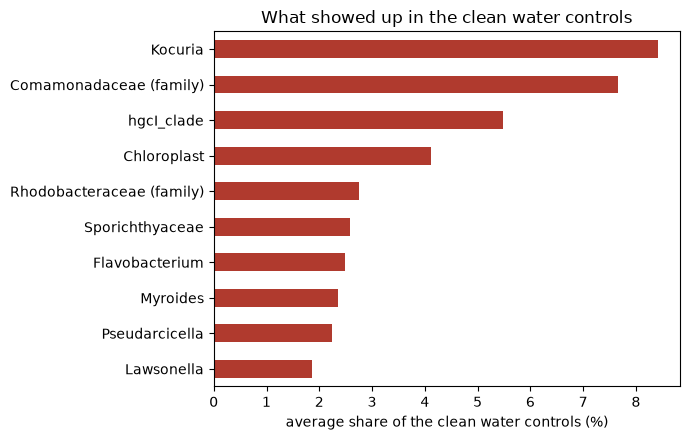

In [9]:
# what is common in the clean water controls? (skin/kit bacteria show up here)
best = basetax['taxon'].map(deepest)
crel = base[controls].div(base[controls].sum(axis=0), axis=1)
ctrl_taxa = crel.groupby(best.reindex(base.index).values).sum().mean(axis=1).sort_values(ascending=False).head(10)
ax=(ctrl_taxa*100)[::-1].plot.barh(figsize=(7,4.5), color='#b03a2e')
ax.set_xlabel('average share of the clean water controls (%)')
ax.set_title('What showed up in the clean water controls'); plt.tight_layout(); plt.show()

## Step 3: What lives in the pond
Now we add up the numbers to see the makeup of the community. The first chart groups microbes into big families and shows how that mix changes across our four sampling spots. The second chart shows the most common individual types overall. We use **shares (percentages)** instead of raw counts, so a sample does not look bigger just because more of its DNA happened to be read.

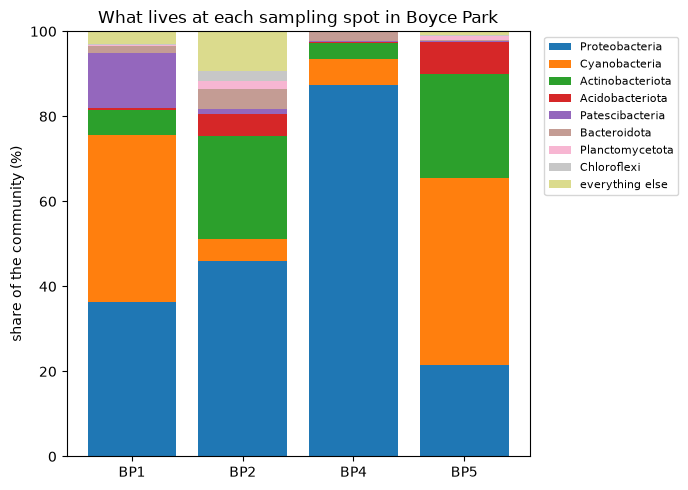

In [10]:
rel = bp.div(bp.sum(axis=0), axis=1)
phy = btax['taxon'].reindex(bp.index).map(lambda t: rank_of(t,'p__') or 'unnamed')
phy_by_sample = rel.groupby(phy.values).sum()
phy_mean = phy_by_sample.mean(axis=1).sort_values(ascending=False)
spot_order=['BP1','BP2','BP4','BP5']
phy_spot = pd.DataFrame({sp: phy_by_sample[[s for s in samples if bmap.loc[s,'spot']==sp]].mean(axis=1) for sp in spot_order})
topP = list(phy_mean.head(8).index)
plot_df = phy_spot.reindex(topP).fillna(0); plot_df.loc['everything else'] = (1-plot_df.sum()).clip(lower=0)
fig,ax=plt.subplots(figsize=(7,5)); bottom=np.zeros(len(spot_order))
for i,p in enumerate(plot_df.index):
    ax.bar(spot_order, plot_df.loc[p]*100, bottom=bottom, label=p, color=plt.cm.tab20(i/max(1,len(plot_df))))
    bottom += (plot_df.loc[p]*100).values
ax.set_ylabel('share of the community (%)'); ax.set_ylim(0,100)
ax.set_title('What lives at each sampling spot in Boyce Park')
ax.legend(bbox_to_anchor=(1.02,1), loc='upper left', fontsize=8); plt.tight_layout(); plt.show()

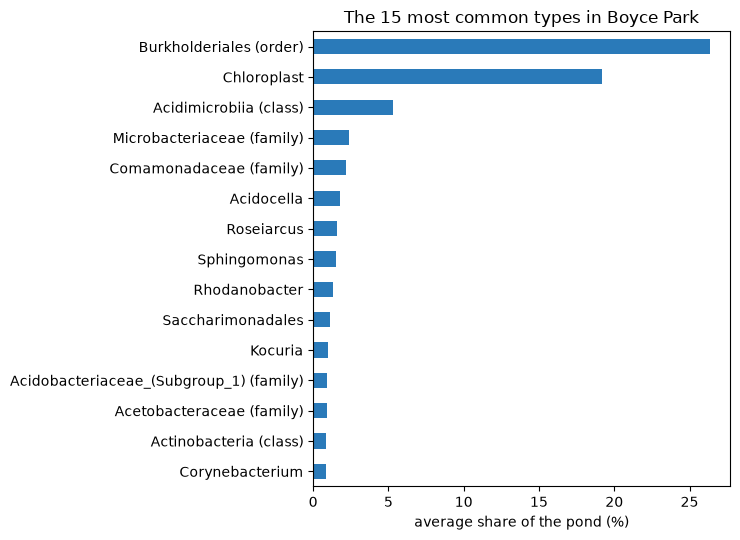

In [11]:
# label each microbe by the most detailed name available (deepest), so the
# dominant Burkholderiales shows up by name instead of as an "unnamed" pile
labels = btax['taxon'].reindex(bp.index).map(deepest)
gen_mean = rel.groupby(labels.values).sum().mean(axis=1).sort_values(ascending=False).head(15)
ax=(gen_mean*100)[::-1].plot.barh(figsize=(7.5,5.5), color='#2a7ab9')
ax.set_xlabel('average share of the pond (%)'); ax.set_title('The 15 most common types in Boyce Park')
plt.tight_layout(); plt.show()

## Step 4: Two comparison pictures
To compare whole communities, we make a **similarity map**. Each dot is one water sample, and samples with similar life sit close together while different ones sit far apart. Under the hood we score how different every pair of samples is, then lay them out on a flat map. Picture A puts our pond next to the rivers and the other sites. Picture B zooms into just our own pond, colored by sampling spot.

In [12]:
def difference_scores(mat):
    n=mat.shape[0]; D=np.zeros((n,n)); rs=mat.sum(1)
    for i in range(n):
        for j in range(i+1,n):
            den=rs[i]+rs[j]; d=(np.abs(mat[i]-mat[j]).sum()/den) if den else 0.0
            D[i,j]=D[j,i]=d
    return D
def make_map(D):
    n=D.shape[0]; A=-0.5*D**2; J=np.eye(n)-np.ones((n,n))/n; B=J@A@J
    val,vec=np.linalg.eigh(B); idx=np.argsort(val)[::-1]; val,vec=val[idx],vec[:,idx]
    pos=val>1e-9; return vec[:,pos]*np.sqrt(val[pos]), val[pos]/val[pos].sum()

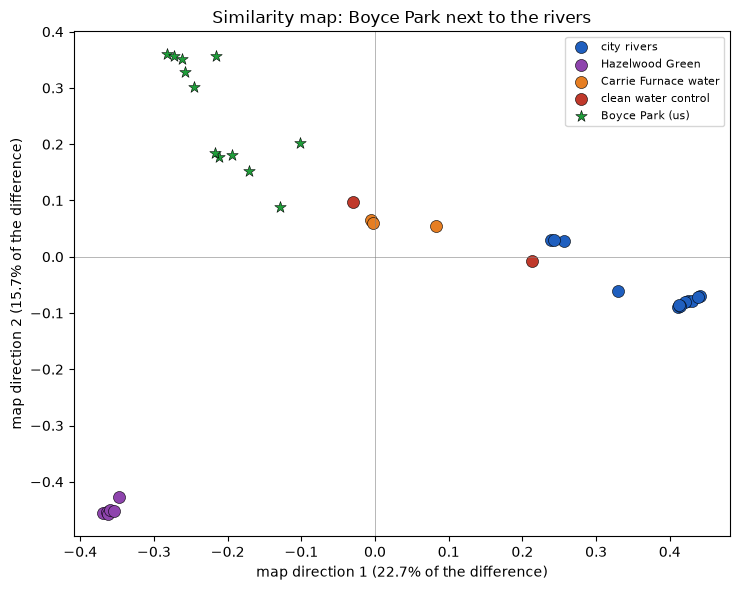

In [13]:
water=[s for s in base.columns if basemap.loc[s,'TreatmentGroup'].startswith('Water') or basemap.loc[s,'TreatmentGroup']=='Uncategorized']
def group_of(s):
    tg=basemap.loc[s,'TreatmentGroup']
    if 'Boyce' in tg or tg=='Uncategorized': return 'Boyce Park (us)'
    if tg in ('Water Point Allegheny','Water Point Monongahela','Water Ohio','Water Braddock'): return 'city rivers'
    if tg=='Water Hazelwood Green': return 'Hazelwood Green'
    if tg=='Water Carrie Furnace': return 'Carrie Furnace water'
    if tg=='Water Control': return 'clean water control'
    return 'other water'
coords,share=make_map(difference_scores(base[water].T.values))
groups=[group_of(s) for s in water]
col={'Boyce Park (us)':'#1f9e3a','city rivers':'#1f5fbf','Hazelwood Green':'#8e44ad','Carrie Furnace water':'#e67e22','clean water control':'#c0392b','other water':'#7f8c8d'}
fig,ax=plt.subplots(figsize=(7.5,6))
for g in ['city rivers','Hazelwood Green','Carrie Furnace water','clean water control','Boyce Park (us)','other water']:
    ix=[i for i,x in enumerate(groups) if x==g]
    if ix: ax.scatter(coords[ix,0],coords[ix,1],s=75,label=g,c=col[g],edgecolor='k',lw=.4,marker='*' if g.startswith('Boyce') else 'o')
ax.set_xlabel('map direction 1 ('+str(round(share[0]*100,1))+'% of the difference)')
ax.set_ylabel('map direction 2 ('+str(round(share[1]*100,1))+'% of the difference)')
ax.set_title('Similarity map: Boyce Park next to the rivers'); ax.legend(fontsize=8)
ax.axhline(0,c='grey',lw=.4); ax.axvline(0,c='grey',lw=.4); plt.tight_layout(); plt.show()

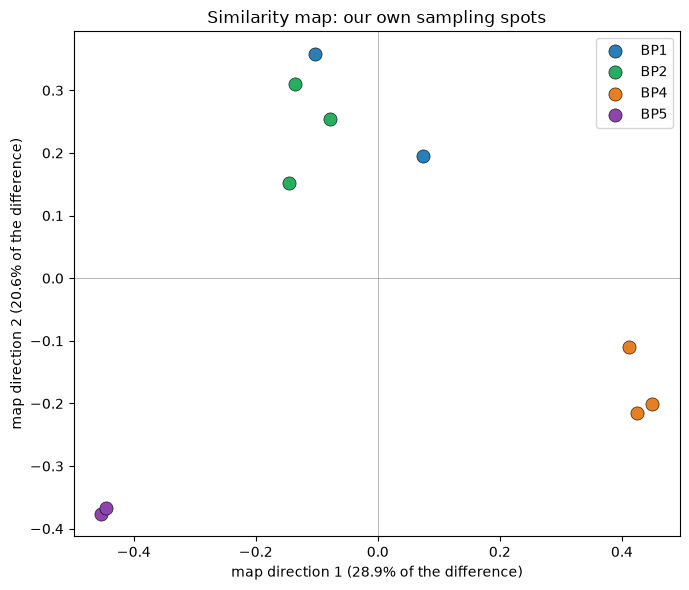

In [14]:
coords_b,share_b=make_map(difference_scores(bp[samples].T.values))
spots=[bmap.loc[s,'spot'] for s in samples]
sc={'BP1':'#2980b9','BP2':'#27ae60','BP4':'#e67e22','BP5':'#8e44ad'}
fig,ax=plt.subplots(figsize=(7,6))
for sp in spot_order:
    ix=[i for i,s in enumerate(spots) if s==sp]
    if ix: ax.scatter(coords_b[ix,0],coords_b[ix,1],s=90,label=sp,c=sc[sp],edgecolor='k',lw=.4)
ax.set_xlabel('map direction 1 ('+str(round(share_b[0]*100,1))+'% of the difference)')
ax.set_ylabel('map direction 2 ('+str(round(share_b[1]*100,1))+'% of the difference)')
ax.set_title('Similarity map: our own sampling spots'); ax.legend()
ax.axhline(0,c='grey',lw=.4); ax.axvline(0,c='grey',lw=.4); plt.tight_layout(); plt.show()

## Step 5: The story

The pond is run by **one iron eating bacterium**, plus **algae**, plus a crew of **acid loving microbes**. That mix is the fingerprint of **acid mine drainage**: acidic, iron rich runoff from old coal mines.


The main characters, in plain words:


| Living thing | What it is | What it tells us |
|---|---|---|
| **Ferrovum** | An iron eating bacterium. The most common thing in the pond. | Only lives in acidic, iron rich mine water. Our top clue. |
| **Eunotia (an alga)** | An acid loving alga that lives by photosynthesis. | The pond is green, but with acid loving algae. |
| **Acidocella and Acidiphilium** | Acid loving bacteria that eat leftover scraps. | Classic mine water residents. |
| **Acidimicrobiaceae** | An acid loving group that recycles iron. | More acidic, iron rich signal. |
| **Rhodanobacter** | A bacterium that copes with acid and pollution. | Points to acidic, polluted water. |
| **Kocuria and Lawsonella** | Skin bacteria, not water bacteria. | Contamination from handling. We ignore them. |

Two surprises:
- The number one microbe: the lab only called it a broad group, but our search named it **Ferrovum**, a mine drainage iron eater.
- Even the algae like acid (the **Eunotia** alga), so the pond is green in an acidic way.


Being honest: the skin bacteria **Kocuria** and **Lawsonella** showed up in the clean water controls, so we dropped them as contamination. The mine drainage microbes were **not** in the controls, so they are real.

## Conclusion: our answer

**The question:** does Boyce Park pond live up to its scenic looks, or is mine drainage shaping who lives there?

**Our answer: mine drainage is shaping it, and it is not just one microbe. A whole set of strains all point the same way.**

When we look up the DNA of our most common microbes, the closest matches are a lineup of acid and iron specialists. These are the specific strains we found, with how close the DNA match was:

| Strain (closest DNA match) | Match | What it is |
|---|---|---|
| **Ferrovum sp. PN-J174** | 99% | The number one microbe in the pond (about 1 in 3 of everything). An iron eater found in mine drainage. |
| **Acidocella aquatica Ok2G** | 99% | An acid loving bacterium. |
| **Acidiphilium rubrum Colony12** | 99% | Another acid lover that also handles iron. |
| **Eunotia naegelii** (an alga) | 99% | An acid loving alga, so even the green life prefers acid. |
| **Klebsormidium nitens** (an alga) | 99% | A second acid tolerant alga. |

None of these belong in a clean, normal pond, and none of them showed up in our clean water controls, so they are real. Together they are the clear fingerprint of **acid mine drainage**.

**So the pretty pond is really acid mine drainage water.** The single clearest sign is **Ferrovum sp. PN-J174**, but a whole crew of acid loving strains backs it up. A quick pH and iron test would confirm it directly.

## Step 6: The tools we used, in plain words

- **Lab files:** a lab read the DNA barcode (the 16S gene) of each microbe and guessed a name. We double check those guesses.
- **BLAST:** an NIH tool that finds the closest DNA match. We trust broad names more than exact species names.
- **Clean water controls:** catch contamination (the skin bacteria), which we then drop.
- **Shares, not raw counts:** so a sample is not judged bigger just because more of its DNA was read.
- **Similarity maps:** place similar samples close together.
- **Left out on purpose:** two optional extras (PICRUSt and a stats test), to keep this simple.

AI helped us write and code, but we understand and stand behind every step.

## Where our facts come from

A few of the main sources behind what we said:

- Ullrich et al. 2016, PLOS ONE (https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0146832)
- Grettenberger et al. 2020, BMC Microbiology (https://bmcmicrobiol.biomedcentral.com/articles/10.1186/s12866-020-01768-w)
- Mühling et al. 2014, Genome Announcements (ASM) (https://journals.asm.org/doi/10.1128/genomea.00834-14)
- San-Martin-Uriz et al. 2020, mSystems (https://journals.asm.org/doi/10.1128/msystems.00867-20)
- Bridge & Johnson 2002 (Reduction of ferric iron by acidophilic heterotrophic bacteria (https://pubmed.ncbi.nlm.nih.gov/11849360/)
- Sievers et al. (https://www.sciencedirect.com/science/article/abs/pii/S0723202011800068)